# Open-Ended Section

**TABLE OF CONTENTS**  

[Distribution Shift Between Training and Test Data](#distribution) <br>
[Feature Importance for the Different Values of the Target Variable](#featimp)  
[Interface Development](#interface)  
[Weighted Mean Experiment Conclusion](#mean)  

## Distribution Shift Between Training and Test Data <a id="distribution"></a>

### 1. Objectives

In this open-ended component, we investigate whether there is a **covariate shift** between the training data (used to tune and select our models) and the test data (used in the Kaggle competition).

Covariate shift occurs when the **distribution of the predictors changes** between train and test, potentially making cross-validation estimates over-optimistic or misleading.

Our objective is to quantify these differences for both **numeric** and **categorical** attributes and to discuss their impact on the robustness and reliability of our final model.

### 2. Methodology

We focus on the features that are available in both datasets (excluding the target `price`, which only exists in the training set, and the variables we ignored since the beggining of the project, since they fall out of the relevant scope - `hasDamage` and `paintQuality%`):

- **Numeric features**: `year`, `mileage`, `tax`, `mpg`, `engineSize`, `previousOwners`
- **Categorical features**: `Brand`, `model`, `transmission`, `fuelType`

The analysis follows three main steps:

1. **Numeric features: summary statistics and KS tests**  
   - For each numeric feature, we compute basic statistics in train vs test (mean, median, standard deviation, quantiles). 
   - We apply the **two-sample Kolmogorov–Smirnov (KS) test** to compare the empirical distributions:
     $$
     H_0: F_{\text{train}}(x) = F_{\text{test}}(x) \quad \forall x
     $$
     A small KS statistic and a large p-value indicate no evidence of distribution shift.

2. **Numeric features: visual comparison**  
   - For each numeric feature, we overlay **normalized histograms / KDEs** of train vs test
   - We visually confirm whether the bulk of the mass and tails overlap.

3. **Categorical features: frequency comparison**  
   - For each categorical feature, we compute the **relative frequency** of each category in train vs. test:
     $$
     p_{\text{train}}(c) = \frac{\#(X_{\text{train}} = c)}{N_{\text{train}}}, \quad
     p_{\text{test}}(c) = \frac{\#(X_{\text{test}} = c)}{N_{\text{test}}}
     $$
   - We then compute the absolute difference $$|p_{\text{train}}(c) - p_{\text{test}}(c)|$$ and rank categories by this value.  
   - This highlights categories whose prevalence changes more strongly between train and test (e.g., brands or typos such as `Toyot` vs `Toyota`).

### 3. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

# Load data
df_train_raw = pd.read_csv("../project_data/train.csv")
df_test_raw  = pd.read_csv("../project_data/test.csv")

# Define feature sets (only features shared by train and test)
target = "price"

num_cols = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize",
    "previousOwners",
]

cat_cols = [
    "Brand",
    "model",
    "transmission",
    "fuelType",
]

### 4. Numeric Features

#### 4.1. Shift Report (Summary + KS Test)

In [3]:
def numeric_shift_report(train: pd.DataFrame,
                         test: pd.DataFrame,
                         num_cols: list[str]) -> pd.DataFrame:
    """
    Compare numeric feature distributions between train and test using:
    - Means / medians
    - KS statistic and p-value

    Returns a DataFrame sorted by KS statistic (descending).
    """
    rows = []

    for col in num_cols:
        if col not in train.columns or col not in test.columns:
            continue

        tr = train[col].dropna()
        te = test[col].dropna()

        if len(tr) == 0 or len(te) == 0:
            continue

        ks_stat, ks_p = ks_2samp(tr, te)

        rows.append({
            "feature": col,
            "train_mean": tr.mean(),
            "test_mean": te.mean(),
            "mean_diff": te.mean() - tr.mean(),
            "train_median": tr.median(),
            "test_median": te.median(),
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
        })

    report = pd.DataFrame(rows)
    report = report.sort_values("ks_stat", ascending=False).reset_index(drop=True)
    return report

numeric_report = numeric_shift_report(df_train_raw, df_test_raw, num_cols)
display(numeric_report)

,feature,train_mean,test_mean,mean_diff,train_median,test_median,ks_stat,ks_pvalue
0,engineSize,1.660136,1.665377,0.005241,1.6,1.6,0.005579,0.487977
1,previousOwners,1.994580,2.006118,0.011538,2.0,2.0,0.005097,0.604666
2,mpg,55.152666,55.210728,0.058062,54.3,54.3,0.004906,0.706193
3,mileage,23004.184088,22952.658921,-51.525167,17300.0,17225.5,0.004469,0.762253
4,year,2017.096611,2017.102299,0.005688,2017.0,2017.0,0.003412,0.956349
5,tax,120.329078,120.569239,0.240162,145.0,145.0,0.002795,0.997094


The table above compares train vs test distributions for our numeric variables using:
- **Mean / median differences** (location shift), and
- The **two-sample Kolmogorov–Smirnov (KS) test** (overall distribution shift).

**Key interpretation:**
- All **KS statistics are extremely small** (from 0.0028 to 0.0056), meaning the empirical distributions of each feature in train and test are *almost identical*.
- All **KS p-values are high** (> 0.05), so we **do not reject** the null hypothesis that train and test come from the same distribution for any numeric feature.
- The **mean and median differences are negligible** in practice:
  - `engineSize`, `previousOwners`, `mpg`, `year`, and `tax` show tiny shifts in central tendency.
  - `mileage` shows the largest mean difference, but it is still small relative to its scale (tens of thousands), and the KS test confirms the overall shape is essentially unchanged.

**Conclusion:**
There is **no evidence of meaningful covariate shift in the numeric features** between the training and test sets. This supports the idea that our cross-validation estimates should transfer reliably to the Kaggle test distribution (at least regarding numeric variables).


#### 4.2. Overlaid Histograms

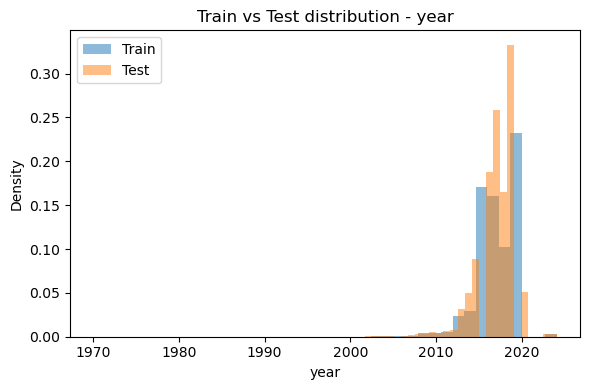

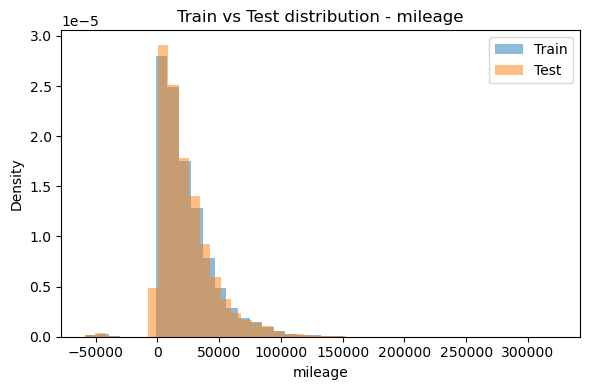

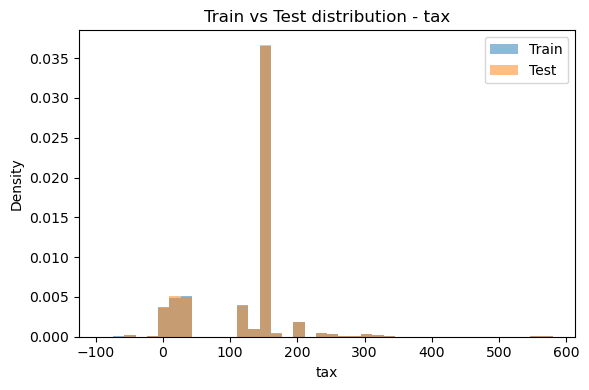

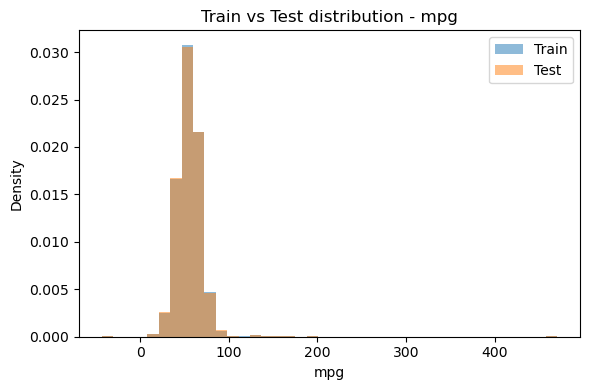

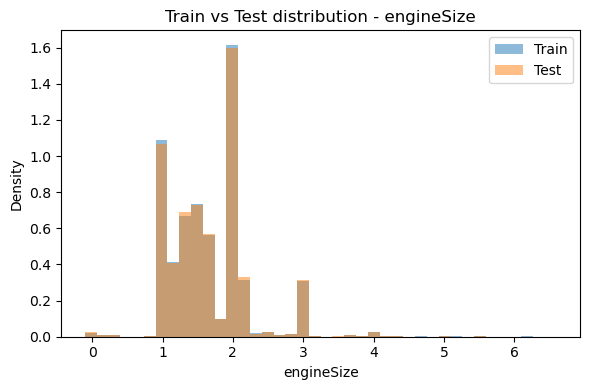

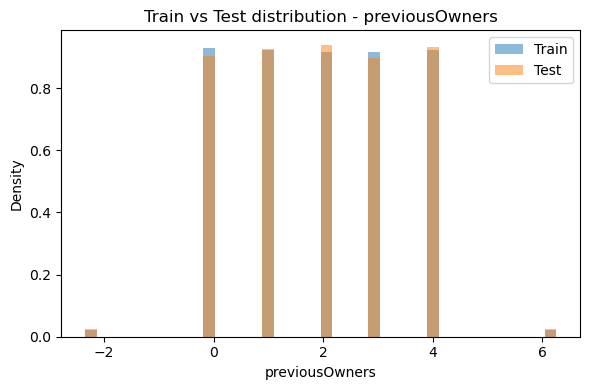

In [5]:
def plot_numeric_distributions(train: pd.DataFrame,
                               test: pd.DataFrame,
                               num_cols: list[str],
                               bins: int = 40):
    """
    Plot normalized histograms of each numeric feature for train vs test.
    """
    for col in num_cols:
        if col not in train.columns or col not in test.columns:
            continue

        fig, ax = plt.subplots(figsize=(6, 4))

        ax.hist(
            train[col].dropna(),
            bins=bins,
            density=True,
            alpha=0.5,
            label="Train"
        )
        ax.hist(
            test[col].dropna(),
            bins=bins,
            density=True,
            alpha=0.5,
            label="Test"
        )

        ax.set_title(f"Train vs Test distribution - {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        plt.show()

plot_numeric_distributions(df_train_raw, df_test_raw, num_cols)

Overall, the train (blue) and test (orange) histograms show **near-complete overlap** for all numeric variables, indicating that the test set is sampled from essentially the same numeric feature distributions as the training set.
 
These plots reinforce that there is **no meaningful covariate shift in numeric features** between training and test, therefore differences between CV performance and Kaggle performance are unlikely to be driven by changes in numeric input distributions, and are more plausibly due to model variance, noise in the target, or category-level effects (to be checked in the categorical shift section).

### 5. Categorical Features

#### 5.1. Shift Report

In [6]:
def categorical_shift_report(train: pd.DataFrame,
                             test: pd.DataFrame,
                             cat_cols: list[str],
                             top_k: int = 10) -> dict[str, pd.DataFrame]:
    """
    For each categorical column, compare normalized value counts
    between train and test.

    Returns a dict mapping column name -> DataFrame with:
    - train_freq
    - test_freq
    - abs_diff
    - rel_diff (relative difference vs train frequency)
    """
    reports: dict[str, pd.DataFrame] = {}

    for col in cat_cols:
        if col not in train.columns or col not in test.columns:
            continue

        vc_train = train[col].value_counts(normalize=True)
        vc_test  = test[col].value_counts(normalize=True)

        # Union of all categories in train and test
        all_cats = sorted(set(vc_train.index) | set(vc_test.index))

        df = pd.DataFrame({
            "train_freq": vc_train.reindex(all_cats, fill_value=0.0),
            "test_freq":  vc_test.reindex(all_cats,  fill_value=0.0),
        })

        df["abs_diff"] = (df["train_freq"] - df["test_freq"]).abs()
        df["rel_diff"] = df["abs_diff"] / df["train_freq"].replace(0, np.nan)

        df = df.sort_values("abs_diff", ascending=False)

        reports[col] = df.head(top_k)

    return reports

cat_reports = categorical_shift_report(df_train_raw, df_test_raw, cat_cols, top_k=10)

for col, rep in cat_reports.items():
    print(f"\n=== Categorical shift – {col} (top {len(rep)} categories by abs_diff) ===")
    display(rep)


=== Categorical shift – Brand (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
Brand,,,,
Toyota,0.057608,0.056520,0.001088,0.018882
Opel,0.116115,0.115076,0.001039,0.008948
Toyot,0.000967,0.001629,0.000662,0.684657
OPEL,0.002270,0.002882,0.000612,0.269819
SKODA,0.000967,0.001567,0.000599,0.619863
skoda,0.001249,0.000752,0.000497,0.398038
ford,0.004123,0.003634,0.000489,0.118626
opel,0.002216,0.002694,0.000478,0.215781
For,0.003935,0.004386,0.000451,0.114554



=== Categorical shift – model (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
model,,,,
C Class,0.065623,0.063822,0.001801,0.027443
Polo,0.027479,0.029201,0.001721,0.062644
Kuga,0.018561,0.020271,0.001710,0.092129
E Class,0.016063,0.017765,0.001702,0.105935
EcoSport,0.010167,0.008647,0.001520,0.149468
Aygo,0.017433,0.015916,0.001517,0.087009
2 Series,0.010771,0.009399,0.001372,0.127381
Fiesta,0.055469,0.056804,0.001335,0.024060
GLA Class,0.006971,0.008052,0.001082,0.155163



=== Categorical shift – transmission (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
transmission,,,,
Automatic,0.188083,0.185950,0.002133,0.011341
Semi-Auto,0.208795,0.210838,0.002043,0.009783
manual,0.010342,0.011645,0.001303,0.125987
anual,0.010799,0.009798,0.001001,0.092661
emi-Auto,0.004365,0.003444,0.000922,0.211157
unknown,0.009268,0.010049,0.000781,0.084269
SEMI-AUTO,0.004150,0.004758,0.000608,0.146480
Automati,0.004083,0.003600,0.000483,0.118331
Manual,0.004916,0.005384,0.000468,0.095289



=== Categorical shift – fuelType (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
fuelType,,,,
Diesel,0.382396,0.388675,0.006278,0.016418
Petrol,0.510260,0.504936,0.005325,0.010435
diesel,0.008044,0.007208,0.000837,0.104026
petrol,0.010019,0.010686,0.000667,0.066620
Hybrid,0.027437,0.026950,0.000487,0.017745
Other,0.002014,0.002413,0.000399,0.197826
iesel,0.008098,0.007740,0.000358,0.044185
etrol,0.010663,0.010341,0.000322,0.030188
Diese,0.007816,0.007521,0.000295,0.037762


The tables above compare the **relative frequency** of each category in the training set vs the test set.  
For each category c, we report:

- `train_freq` = $$p_{\text{train}}(c)$$
- `test_freq`  = $$p_{\text{test}}(c)$$
- `abs_diff`   = $$|p_{\text{train}}(c) - p_{\text{test}}(c)|$$
- `rel_diff`   = $$\frac{|p_{\text{train}}(c) - p_{\text{test}}(c)|}{p_{\text{train}}(c)}$$ (rel_diff may be undefined / unstable if the category is very rare)

<br>

**BRAND:**
- The main brands (Toyota, Opel, ...) show **tiny absolute differences** (around 0.001), meaning their prevalence is essentially the same in train and test.
- The largest `rel_diff` values occur for **very rare labels**, which are **data-quality artifacts** (typos, truncations, capitalization differences) rather than true distribution shift.
- Importantly, even when `rel_diff` looks large, the **absolute differences are extremely small** (< 0.001), so these categories have little impact on overall distribution.

<br>

**MODEL:**
- The most frequent models in this “top-10 by abs_diff” list differ by about **0.001 to 0.002** in absolute frequency. These small shifts are consistent with **sampling variability**, rather than a structural mismatch between datasets.
- `rel_diff` is moderately larger for less common models (**T-Cross**, **GLA Class**, ...), again because relative differences inflate when the base frequency is smaller.

<br>

**TRANSMISSION:**
- The main transmission categories (**Automatic**, **Semi-Auto**, **Manual**) have **very small absolute differences**, which indicates no meaningful shift.
- Several entries in the top differences are clearly **dirty duplicates**: **"manual"**, **"Manual"**, **"anual"**, etc, representing inconsistent casing/truncation rather than a change in the underlying market.

<br>

**FUEL TYPE:**
- The core fuel types (**Diesel**, **Petrol**, **Hybrid**) show small shifts. The largest absolute differences are still small (around 0.005-0.006 for Diesel/Petrol), which is not indicative of strong covariate shift.
- The remaining categories again look like **noisy labels**: **"diesel"**, **"petrol"**, **"PETROL"**, **"Diesel"** variants, and truncated strings such as **"iesel"**, **"etrol"**, **"Diese"**.
- Because Diesel and Petrol are common, their `rel_diff` values remain small, reinforcing that the global fuel mix is consistent.

<br>

**All categorical distriutions appear to be stable**; however, string normalization is clearly important to prevent the model from treating duplicates as distinct categories.

#### 5.2. Simple Visuals

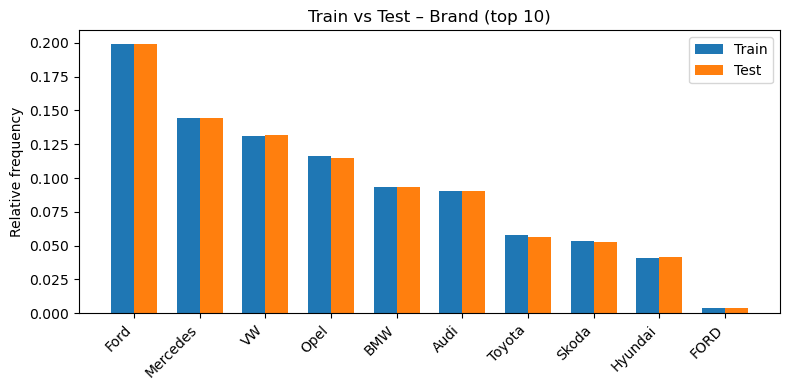

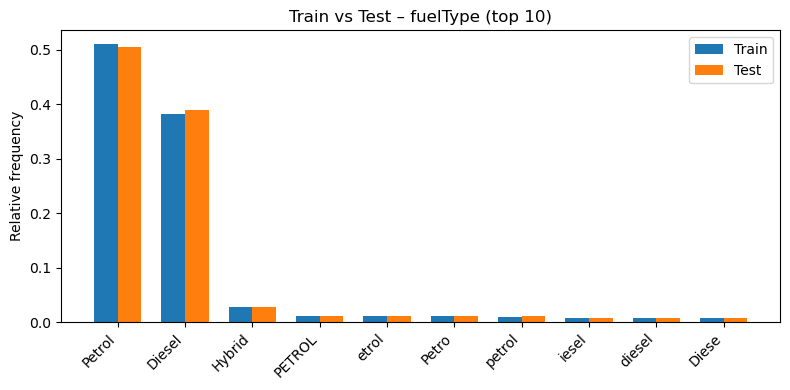

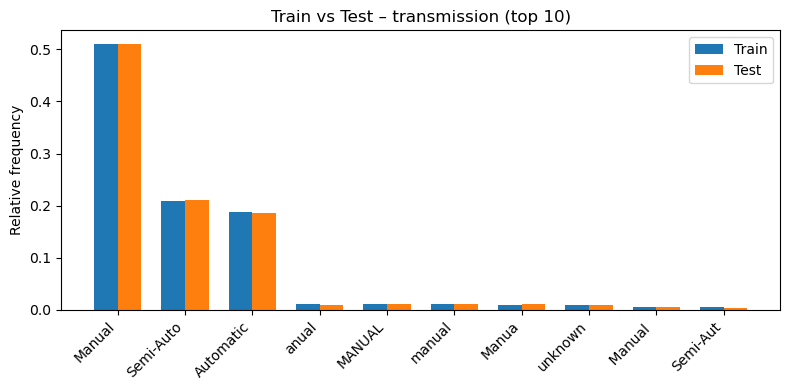

In [7]:
def plot_categorical_distributions(train: pd.DataFrame,
                                   test: pd.DataFrame,
                                   col: str,
                                   top_k: int = 10):
    """
    Plot side-by-side bar chart of top_k categories in train vs test
    for a given categorical feature.
    """
    vc_train = train[col].value_counts(normalize=True).head(top_k)
    vc_test  = test[col].value_counts(normalize=True).reindex(vc_train.index, fill_value=0.0)

    x = np.arange(len(vc_train))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(x - width/2, vc_train.values, width, label="Train")
    ax.bar(x + width/2, vc_test.values,  width, label="Test")

    ax.set_xticks(x)
    ax.set_xticklabels(vc_train.index, rotation=45, ha="right")
    ax.set_ylabel("Relative frequency")
    ax.set_title(f"Train vs Test – {col} (top {top_k})")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Example: main categorical variables
for col in ["Brand", "fuelType", "transmission"]:
    plot_categorical_distributions(df_train_raw, df_test_raw, col, top_k=10)

The bar plots above provide a direct visual comparison of the **top categories** in the training and test sets for the main categorical variables. They complement the numerical shift tables by showing the *practical magnitude* of any differences, which is basically 0.

**Conclusion:**

Across all categorical variables, the dominant pattern is:
1. **No meaningful distribution shift** (train and test categorical distributions are well aligned) in the main categories.
2. Apparent “differences” are largely explained by **rare dirty categories** (typos / capitalization / truncation) - which inflate `rel_diff` but remain negligible in `abs_diff`.

**This supports the assumption that train and test are drawn from a similar population**, while also providing strong justification for our earlier preprocessing step of **string cleaning and category harmonization** to prevent spurious categories from degrading model generalization.

As a result, model performance differences between cross-validation and Kaggle evaluation are unlikely to be caused by categorical covariate shift, and can instead be attributed to model variance, noise in the target variable, or limitations of the modeling assumptions.

### 6. Impact on Model Generalization

From a modeling perspective, the analysis indicates that:

- Both the training and test data appear to be drawn from the **same underlying data-generating process**, with no strong evidence of covariate shift.  
- This supports the validity of our **cross-validation performance estimates**: the error we observe under CV should be a good approximation to the error on the Kaggle test set.  
- Our preprocessing choices (specifically cleaning `Brand`, `model`, `transmission` and `fuelType`) are justified and help further reduce potential mismatch between train and test.

In practical terms, this means we **do not need to introduce complex correction mechanisms** (such as importance weighting or domain adaptation) to compensate for distribution shift. Instead, we can focus on improving the modeling pipeline itself (feature engineering, tuning, ensembling) with reasonable confidence that gains will translate to the test data.

### 7. Limitations of this analysis

This analysis is intentionally focused on the **marginal distributions** of each feature. Possible extensions would include:
- Analysing **joint distributions or interactions** (`Brand` × `year`, `fuelType` × `engineSize`, ...) for more subtle forms of shift;
- Comparing **residual distributions** of the final model per brand or fuel type to detect localized under or over-prediction;
- Repeating the same experiment if a future version of the dataset is collected under different market conditions, to monitor **temporal drift**.

---

## Feature Importance for the Different Values of the Target Variable <a id="featimp"></a>

### 1. Objective
Global feature importance can hide heterogeneity: the factors that determine *low-priced* cars may differ from those that drive *high-priced* cars.  
In this section, we segment the training data into **three price tiers** (low / mid / high) using **quantiles**, and we quantify how feature importance changes across tiers.

### 2. Methodology
1. Fit the **best stacking model** (HGB + RF + ET) using the full preprocessing/encoding pipeline, training on `log1p(price)`.
2. Create 3 segments based on the target `price`:
   - Low-price: bottom 33%
   - Mid-price: middle 33%
   - High-price: top 33%
3. For each segment, compute **permutation importance** on that subset:
   - We permute one feature at a time and measure the degradation in performance (MAE).
   - A larger degradation indicates the model relies more on that feature for that segment.

This produces a segment-specific view of the model's decision logic and supports business interpretation of *what drives price in different market tiers*.

### 3. Setup

In [1]:
# Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb

# Define target
TARGET_COL = "price"

### 4. Permutation importance per segment (MAE-based)

- design matrix (pre-scale): (75973, 14)
- design matrix (scaled): (75973, 14)
- stacking model trained
price
high    25820
low     25082
mid     25071
Name: count, dtype: int64


,feature,delta_MAE_mean,delta_MAE_std
0,model,1.233518e+03,6.388614e+00
1,year,1.129390e+03,5.200748e+00
2,mileage,8.792507e+02,4.634081e+00
3,mpg,3.096396e+02,2.271625e+00
4,engineSize,3.095447e+02,2.243929e+00
5,Brand,2.655581e+02,2.569083e+00
6,tax,1.117307e+02,1.426570e+00
7,fuelType_PETROL,8.187394e+01,1.215559e+00
8,fuelType_DIESEL,5.610238e+01,8.953334e-01
9,transmission_AUTOMATIC,3.336851e+01,6.332653e-01


,feature,delta_MAE_mean,delta_MAE_std
0,model,1502.057861,6.837386
1,year,1206.830643,4.910699
2,mileage,1031.671111,8.434463
3,engineSize,793.586820,3.432574
4,Brand,495.857134,3.388875
5,mpg,492.653012,5.034435
6,tax,118.969278,2.245600
7,fuelType_PETROL,96.446471,1.498457
8,fuelType_DIESEL,66.913404,2.004926
9,transmission_AUTOMATIC,66.117789,0.494957


,feature,delta_MAE_mean,delta_MAE_std
0,model,2.999103e+03,2.040048e+01
1,engineSize,2.097242e+03,1.219814e+01
2,mpg,1.760320e+03,1.200577e+01
3,mileage,1.593778e+03,1.347953e+01
4,year,1.334181e+03,1.071425e+01
5,Brand,1.027324e+03,9.954708e+00
6,fuelType_PETROL,2.625662e+02,4.007616e+00
7,tax,2.218911e+02,3.443150e+00
8,fuelType_DIESEL,1.456258e+02,3.982124e+00
9,transmission_AUTOMATIC,1.135932e+02,1.306752e+00


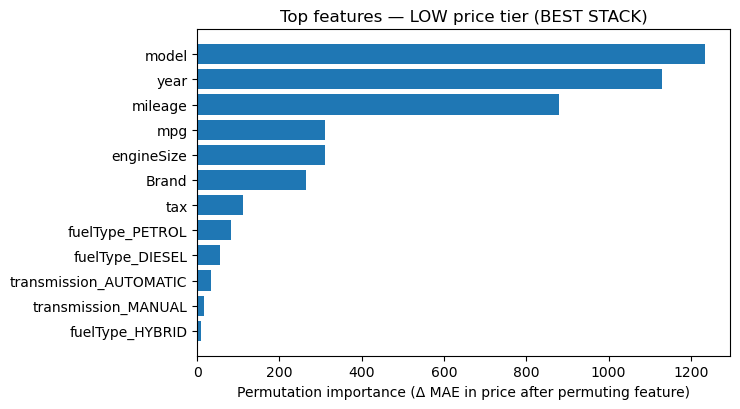

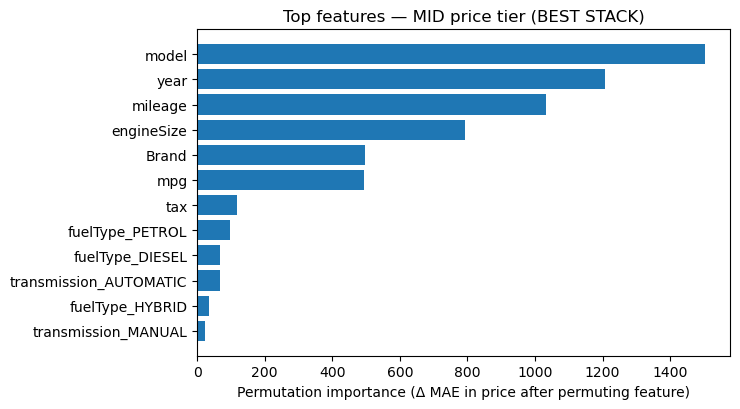

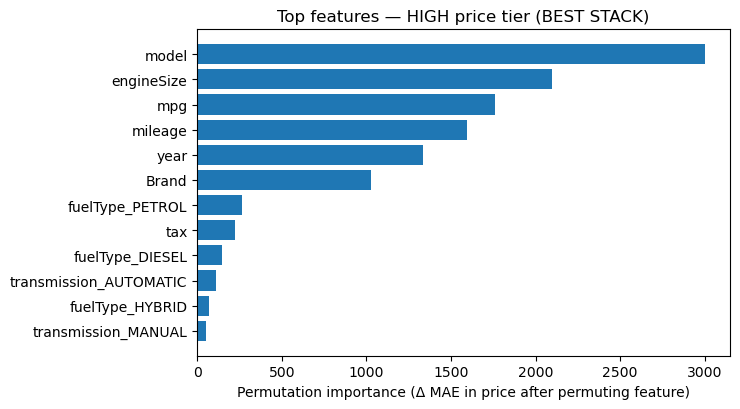

,feature,rank_low,imp_low,rank_mid,imp_mid,rank_high,imp_high,avg_rank
0,model,1,1.233518e+03,1,1502.057861,1,2.999103e+03,1.000000
1,year,2,1.129390e+03,2,1206.830643,5,1.334181e+03,3.000000
2,mileage,3,8.792507e+02,3,1031.671111,4,1.593778e+03,3.333333
3,engineSize,5,3.095447e+02,4,793.586820,2,2.097242e+03,3.666667
4,mpg,4,3.096396e+02,6,492.653012,3,1.760320e+03,4.333333
5,Brand,6,2.655581e+02,5,495.857134,6,1.027324e+03,5.666667
6,tax,7,1.117307e+02,7,118.969278,8,2.218911e+02,7.333333
7,fuelType_PETROL,8,8.187394e+01,8,96.446471,7,2.625662e+02,7.666667
8,fuelType_DIESEL,9,5.610238e+01,9,66.913404,9,1.456258e+02,9.000000
9,transmission_AUTOMATIC,10,3.336851e+01,10,66.117789,10,1.135932e+02,10.000000


In [ ]:
# BEST MODEL: Stacking HGB + RF + ET, log-target, drop previousOwners
# Permutation importance computed as ΔMAE (in original price scale)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler


# 0) LOAD TRAIN
try:
    df_train_raw = pd.read_csv("train.csv")
except:
    df_train_raw = pd.read_csv("../../project_data/train.csv")

target = "price"

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in df_train_raw.columns), None)

df_train = df_train_raw.drop(columns=[ID_COL]).copy() if ID_COL is not None else df_train_raw.copy()


# 1) SETTINGS (our best stacking model)
RANDOM_STATE = 42

DROP_FROM_MODEL = ["previousOwners"]

numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]
categorical_features = ["Brand", "model", "transmission", "fuelType"]

params = {
    "hgb": {
        "max_iter": 1000,
        "learning_rate": 0.1,
        "max_depth": 20,
        "max_leaf_nodes": 191,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0,
        "random_state": RANDOM_STATE
    },
    "rf": {
        "n_estimators": 1000,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": 0.33,
        "max_depth": 20,
        "bootstrap": True,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "et": {
        "n_estimators": 800,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 1,
        "max_features": 0.7,
        "bootstrap": False,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
}

high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# 2) SPLIT X/y (FULL TRAIN)
X_full = df_train.drop(columns=[target]).copy()
y_full = df_train[target].astype(float).copy()
y_full_log = np.log1p(y_full)


# 3) FIT + TRANSFORM ON FULL TRAIN
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, year_state)

mileage_state = fit_mileage_imputer(X_full, "mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, mileage_state)

engine_state = fit_engine_size_imputer(X_full, "engineSize")
X_full = transform_engine_size_imputer(X_full, engine_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

mpg_state = fit_mpg_imputer(X_full, "mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, mpg_state)

owners_state = fit_previous_owners_imputer(X_full, "previousOwners", "year", "mileage")
X_full = transform_previous_owners_imputer(X_full, owners_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# Drop previousOwners 
X_full = X_full.drop(columns=DROP_FROM_MODEL, errors="ignore")


# 4) ENCODING (fit ONLY on full train targets; no leakage)
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full) 
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_final = pd.concat(
    [X_full[numeric_features], X_full_high, X_full_low],
    axis=1
)
print(f"- design matrix (pre-scale): {X_full_final.shape}")


# 5) SCALING (for Ridge meta-model)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full_final)
X_scaled = pd.DataFrame(X_scaled, columns=X_full_final.columns, index=X_full_final.index)
print(f"- design matrix (scaled): {X_scaled.shape}")


# 6) FIT BEST STACKING MODEL ON FULL TRAIN (log-target training)
estimators = [
    ("hgb", HistGradientBoostingRegressor(**params["hgb"])),
    ("rf",  RandomForestRegressor(**params["rf"])),
    ("et",  ExtraTreesRegressor(**params["et"]))
]
meta_model = Ridge(alpha=3.0)

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5, # internal stacking CV
    n_jobs=1
)

stack.fit(X_scaled, y_full_log)
print("- stacking model trained")


# 7) PRICE SEGMENTS (based on ORIGINAL price)
def price_segments(y_price: pd.Series, q=(0.33, 0.66)) -> pd.Series:
    y_price = pd.Series(y_price).astype(float)
    q1, q2 = y_price.quantile(q[0]), y_price.quantile(q[1])
    return pd.cut(
        y_price,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["low", "mid", "high"],
        include_lowest=True
    )

seg = price_segments(y_full)
print(seg.value_counts())


# 8) PERMUTATION IMPORTANCE PER SEGMENT (ΔMAE in price scale)

def neg_mae_price_from_log_model(estimator, X, y_true_price):
    """
    Returns NEGATIVE MAE. 
    sklearn permutation_importance assumes 'higher is better'.
    """
    pred_log = estimator.predict(X)
    pred_price = np.expm1(pred_log)
    pred_price = np.maximum(pred_price, 0)
    
    return -mean_absolute_error(y_true_price, pred_price) # RETURN NEGATIVE MAE HERE

def perm_importance_by_segment_price(
    estimator,
    X_scaled_df: pd.DataFrame,
    y_price: pd.Series,
    seg: pd.Series,
    n_repeats=8,
    random_state=42,
    top_k=15
):
    out = {}
    for name in ["low", "mid", "high"]:
        mask = (seg == name).values
        Xs = X_scaled_df.loc[mask]
        ys = y_price.loc[mask]

        r = permutation_importance(
            estimator,
            Xs, ys,
            scoring=neg_mae_price_from_log_model, # Use the negative scorer
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )

        df_imp = pd.DataFrame({
            "feature": X_scaled_df.columns,
            "delta_MAE_mean": r.importances_mean, # This will now be positive
            "delta_MAE_std":  r.importances_std
        }).sort_values("delta_MAE_mean", ascending=False).reset_index(drop=True)

        out[name] = df_imp.head(top_k)

    return out

imp_seg = perm_importance_by_segment_price(
    stack, X_scaled, y_full, seg,
    n_repeats=8, random_state=RANDOM_STATE, top_k=15
)

display(imp_seg["low"])
display(imp_seg["mid"])
display(imp_seg["high"])



# 9) PLOTS 
def plot_imp(imp_dict, top_k=12):
    for name, df in imp_dict.items():
        dfp = df.head(top_k).iloc[::-1]
        plt.figure(figsize=(7.5, 4.2))
        plt.barh(dfp["feature"], dfp["delta_MAE_mean"])
        plt.xlabel("Permutation importance (Δ MAE in price after permuting feature)")
        plt.title(f"Top features - {name.upper()} price tier (BEST STACK)")
        plt.tight_layout()
        plt.show()

plot_imp(imp_seg, top_k=12)


# 10) RANK COMPARISON TABLE
def compare_ranks(imp_dict, top_k=15):
    feats = set()
    for df in imp_dict.values():
        feats |= set(df["feature"].head(top_k))
    feats = sorted(feats)

    T = pd.DataFrame({"feature": feats})
    for name, df in imp_dict.items():
        ranks = {f: i+1 for i, f in enumerate(df["feature"].tolist())}
        imps  = dict(zip(df["feature"], df["delta_MAE_mean"]))
        T[f"rank_{name}"] = [ranks.get(f, np.nan) for f in feats]
        T[f"imp_{name}"]  = [imps.get(f, 0.0) for f in feats]

    T["avg_rank"] = T[[c for c in T.columns if c.startswith("rank_")]].mean(axis=1, skipna=True)
    T = T.sort_values("avg_rank").reset_index(drop=True)
    return T

rank_table = compare_ranks(imp_seg, top_k=15)
display(rank_table.head(25))

We trained our **final stacking model on the full training set** (log-target) and then computed **permutation importance separately within each price tier** (low / mid / high), where importance is measured as the change in MAE (∆MAE in price) after permuting each feature inside the segment - the higher the change, the more importante the feature.

---
**1) Low-price tier - main drivers**

In the **low-price** segment, the strongest drivers are:

- `model` (largest magnitude): the model heavily relies on the target-encoded `model` even among cheaper cars, suggesting that the specific model identity captures strong baseline price differences.
- `year` and `mileage`: depreciation/usage effects are dominant, which matches intuition for lower-value vehicles.
- `engineSize` and `mpg`: technical specs still matter, but way less than depreciation and identity.
- `Brand`: contributes, but below the top depreciation variables.

**Takeaway (low tier):** pricing behaves mostly like **depreciation + model identity**. Condition/use (year/mileage) features are key.

---
**2) Mid-price tier - transition regime**

In the **mid-price** segment, the ordering is similar but the relative weights shift:

- `model` remains the top driver.
- `year` and `mileage` remain very important, but `engineSize` grows in importance relative to the low tier (specification starts to matter more).
- `Brand` also becomes more influential than in the low tier, but remains lower than the others.

**Takeaway (mid tier):** the model uses a more balanced mix of **depreciation (year/mileage)** and **specification/identity (engineSize, Brand/model)**.

---
**3) High-price tier - specification + identity dominate**

In the **high-price** segment, feature importance magnitudes increase substantially, showing the model is highly sensitive to a smaller set of key variables:

- `model` becomes overwhelmingly dominant (largest magnitude by far).
- `engineSize` and `mpg` become much more important than in low/mid tiers.
- `mileage` and `year` remain critical, but the importance structure indicates that in the high tier, “what the car is” (model/specification) drives valuation strongly.
- `Brand` shows a large jump in magnitude compared to the lower tiers.

**Takeaway (high tier):** valuation is driven primarily by **model identity + technical specification**, with depreciation still relevant but relatively less explanatory on its own.

---
**Cross-tier comparison (rank table)**

The rank comparison table confirms a stable hierarchy:
- `model`, `age`, `mileage`, `engineSize`, `mpg`, and `Brand` consistently dominate the predictive logic across segments.
- However, the **magnitude** of importance grows strongly with the price tier, especially for:
  - `model`
  - `engineSize`
  - `mpg`
  - `Brand`

This supports a clear pattern:  
- At the low end, **depreciation signals** explain most variation.  
- At the high end, **identity/specification signals** explain most variation.

<br>

### 5. Conclusion

This segment-based analysis shows that even though we trained a single global model, its learned pricing mechanism is **tier-dependent**:

- **Low-price cars:** dominated by depreciation/usage (`age`, `mileage`) plus baseline model effects.  
- **High-price cars:** dominated by product identity and specs (`model`, `engineSize`, `mpg`, `Brand`), with depreciation remaining important but no longer the primary source of variation.

This provides additional insight beyond global feature importance and motivates potential future extensions such as **tier-specific calibration** or training **specialized models per price segment**.

---
## Interface Development <a id="interface"></a>

### 1. Motivation and Goals

<div style="text-align: justify; max-width: 1300px; margin: 1rem auto;">

- After selecting the final model, it would not be practical for end users to rely on scripts or notebooks to generate predictions. An interface is required to allow direct submission of input data (e.g., file uploads) and immediate access to results.

- The main objective was to develop an interface that deploys our best-performing model and supports the Cars4You workflow: enabling employees to quickly evaluate vehicles for resale by submitting car attributes and receiving predicted prices.

</div>

### 2. Implementation Overview

<div style="text-align: justify; max-width: 1300px; margin: 1rem auto;">

- We started by creating the app.py entry point and adding a placeholder page for predictions to validate the Streamlit multi-page structure early (navigation, layout, and routing).

- After confirming the page switching worked correctly, we implemented the shared UI styling (page configuration and custom CSS) and defined the basic user flow from the landing page to the prediction page.

- We then built the 1_Predict.py page with two submission modes: multiple cars (CSV upload) and single car (form).

- After that, we started the ideation process of how to transmit the input data and retrieve the predicted prices. We decided to separate the codebase into two layers: an interface layer (Streamlit pages, UI logic) and a backend layer (preprocessing, model fitting and inference). This separation ensures that the UI only handles input validation and DataFrame construction, while the backend encapsulates the full pipeline required to produce consistent predictions.

- To replicate the full pipeline from the final stacking implementation, we needed to reuse the helper functions defined in `05_0_preproc_helpers.ipynb`. Since notebooks are not convenient to import as modules, we converted it into a Python script to simplify the import workflow. We did this by running the following command in the terminal: `jupyter nbconvert --to script 05_0_preproc_helpers.ipynb`.

- After that, we imported the generated .py file, selected the required helper functions and constants, and defined the necessary setup.

- Then, we defined our best stacking hyperparameters to use and implemented two backend functions - fit_stacking_best and predict_stacking_best - that replicate the pipeline used in the stacking notebooks: 
    - fit_stacking_best: trains the pipeline on the training set: it normalizes categorical strings, imputes/repairs numeric and categorical fields, resolves invalid/ambiguous categories for Brand, model, transmission, and fuelType, then drops previousOwners (ablation). It encodes high-cardinality features (Brand, model) with target encoding and the remaining categoricals with one-hot encoding, applies StandardScaler and fits a StackingRegressor (HGB + RF + ET) with a Ridge meta-learner (alpha=4.0). The model is trained on log1p(price) and returns a fitted bundle containing all states (transformers, encoders, scaler, final model and training column schema) needed for inference.
    - predict_stacking_best: applies the stored fitted bundle to new data: it performs the same string normalization and preprocessing steps using the saved states, drops previousOwners, applies the fitted target encoder and one-hot encoder, aligns features to the training matrix columns, scales with the fitted scaler, and generates predictions. Outputs are converted back to the original price scale via expm1 (with non-negativity clipping) and optionally include carID when available.

- To connect the frontend (1_Predict.py) with the backend (stack_best_config.py), we imported the backend entry points (fit_stacking_best, predict_stacking_best) and the training assets (X, y and the valid-category dictionaries) directly into the Streamlit page. The model is fitted once and reused across interactions via `@st.cache_resource(get_fitted())`, so the UI can repeatedly call predict_stacking_best without retraining on every rerun. For single-car submissions, the form inputs are collected and stored as a single-row DataFrame with a fixed column order (SINGLE_COLS). This DataFrame is then passed to predict_stacking_best, which applies the full preprocessing + encoding + scaling pipeline and returns a one-row prediction table (from which the final price is displayed).

- The interface is deployed as a locally hosted Streamlit app, executed via `streamlit run interface/app.py` (see `interface/README.md` for setup and usage instructions).

</div>

### 3. Final Results

<div style="text-align: justify; max-width: 1300px; margin: 1rem auto;">

<p> - The interface has the following structure:</p>

<pre style="white-space: pre; font-family: monospace; margin: 0;">
interface/
├── README.md
├── app.py
├── backend/
│   ├── preproc_helper.py
│   └── stack_best_config.py
└── pages/
    └── 1_Predict.py
</pre>

</div>


<div style="text-align: justify; max-width: 1300px; margin: 1rem auto;">

- The app.py file generates the homepage. This page includes an Info button that opens a modal with brief instructions on how to submit data for prediction. The main action is the Predict button, which redirects the user to the predictions page.

- On the predictions page, the user can choose between two input modes: Multiple cars (CSV upload) or Single car (form).

- If the user selects "Multiple cars (CSV)", the interface requests them to upload a CSV file and displays the expected file structure. After inference, the app shows a preview of the generated output (including the carID column and the predicted price) and allows the user to download the resulting CSV.

- If the user selects "Single car", the user fills out a form with the car's characteristics. After submission, the predicted price is displayed directly on screen.

- We implemented both modes because they match realistic usage scenarios: in practice, a user may need predictions for many vehicles at once (batch upload), but may also want to evaluate a single vehicle quickly. Requiring a full CSV for a single prediction would be unnecessarily inconvenient.

</div>

### 4. Conclusions

- Our interface work completes the project by turning the final stacking model into a usable tool that aligns with the goal of enabling employees to obtain price estimates without relying on notebooks or manual scripts. By integrating the full preprocessing and inference pipeline into a locally hosted Streamlit application, we ensured that predictions are generated consistently with the model assessed during development, while offering two practical submission modes (CSV batch and single-car form) that reflect realistic workflows.

- Overall, this delivers a more complete and presentable solution for a client-facing context. In addition, Streamlit enabled rapid development of an interactive interface directly in Python, making UI implementation significantly more practical than a traditional HTML/JavaScript front end. Common interaction patterns (such as modals, form-based inputs, file uploads and instant result previews) can be implemented more quickly, while still providing a clear and user-friendly experience.

# Weighted Mean Experiment Conclusion <a id="mean"></a>

Overall, this ensemble experiment did not yield substantially better results than those obtained by the individual models included in the weighted average. Within this weighted-mean setup, the best result achieved corresponds to an RMSE of 2118.7 and a MAE of 1266.3, obtained when using the full dataset without feature selection or feature engineering (Section 3.1). A likely explanation is that all combined models belong to the same family of tree-based methods and therefore tend to make similar types of errors. As discussed in previous sections, ensemble methods benefit most when combining models from different families that capture complementary patterns and fail in different regions of the feature space.

Although models from other families, such as neural networks or linear models, were also considered in this experiment, they did not consistently improve performance. This is likely because these models did not reach a sufficiently strong level of performance on their own. As a result, even in cases where they performed slightly better than tree-based models, their improvements were not large enough to compensate for the errors made by the stronger models. Consequently, instead of adding complementary information, these weaker models introduced additional noise into the ensemble, limiting its ability to improve upon the best individual predictors.

The implementation and resulting metrics of this experiment are shown in the notebook `05_09_Weighted_Mean.ipynb`.